# Clustering pages by text-line layout

This notebook demonstrates `archival_structures.analysis.page_layout_clustering`: clustering
whole pages by the spatial layout of their text lines (not regions -- region detection is too
crude and merges visually distinct elements). It builds on
`archival_structures.analysis.grid_analysis.GridPattern`, which grids each page by its line
geometry and computes a TF-IDF vector per page over small recurring grid patterns; this module
just clusters those vectors with HDBSCAN.

One implementation detail worth knowing if you reuse this elsewhere: TF-IDF row norms vary a
lot between pages (a page with more text has a "longer" vector even if its pattern *composition*
is identical to a shorter page), which would otherwise dominate Euclidean distance and produce
all-noise clustering. `cluster_page_layouts` L2-normalises the rows before clustering to correct
for that.

This uses `NL-HaNA_2.10.50_1`, one of the book-of-openings inventory numbers, and -- as with the
line-clustering demo -- **splits each two-page opening into single pages first** with
`archival_structures.analysis.opening_detection.split_inventory_into_pages`. A page's layout is a
property of *that page*, not of the two-page scan it happened to be photographed alongside, so
clustering should operate on pages, not opening-wide scans.

In [1]:
from pathlib import Path

import pandas as pd
from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, split_inventory_into_pages, get_opening_features,
)
from archival_structures.analysis.page_layout_clustering import cluster_page_layouts

INSTITUTE = 'NL-HaNA'
ARCHIVE = 'NL-HaNA_2.10.50'
INVENTORY_NUM = 'NL-HaNA_2.10.50_1'
PAGEXML_DIR = Path('../../data/PageXML') / INSTITUTE / ARCHIVE / INVENTORY_NUM
THUMB_DIR = Path('../../data/thumbs') / INSTITUTE / ARCHIVE / INVENTORY_NUM

assert PAGEXML_DIR.exists(), PAGEXML_DIR
assert THUMB_DIR.exists(), THUMB_DIR

## Load a sample of scans, split openings into pages, and cluster them

`GridPattern` turns out not to tolerate pages with zero lines well (an empty page's all-zero
grid pollutes the global pattern vocabulary enough that clustering degenerates to all-noise) --
filter those out, which a real "page" should rarely be anyway.

In [2]:
xml_paths = sorted(PAGEXML_DIR.glob('*.xml'))[:60]
scans = [pagexml_parser.parse_pagexml_file(str(xml_path)) for xml_path in xml_paths]
scans_by_id = {scan.id: scan for scan in scans}
print(f"loaded {len(scans)} scans")

structure = classify_inventory_structure(scans)
print(f"inventory structure: {structure.structure_type} {structure.type_counts}")

all_pages = split_inventory_into_pages(scans, structure=structure)
pages = [page for page in all_pages if len(page.get_lines()) > 0]
page_by_id = {page.id: page for page in pages}
print(f"{len(scans)} scans -> {len(all_pages)} pages -> {len(pages)} with at least one line")

clusters, grid_pattern = cluster_page_layouts(pages, unit_size=50, pattern_size=3, min_cluster_size=4)
print("\ncluster sizes:")
print(clusters.value_counts().sort_index())

loaded 60 scans
inventory structure: book_of_openings {'opening': 45, 'single_page': 14, 'odd_shaped': 1}


60 scans -> 105 pages -> 100 with at least one line
done setting base grid points
took 0.0 seconds (total: 0.0)
done setting line grid_points for 100 docs, with 100 x and 119 y points
took 0.1 seconds (total: 0.1)


done computing patterns, 387 distinct patterns
took 1.2 seconds (total: 1.3)
done computing tf-idf of patterns
took 0.0 seconds (total: 1.3)

cluster sizes:
cluster
-1    83
 0     7
 1    10
Name: count, dtype: int64


## What the clustering is based on: the grid-pattern fingerprint

`GridPattern` turns each page into a vector of recurring *local geometry* patterns, with no
notion of line type or text content (that's what `line_clustering` and the relational extension
below add):

1. Rasterise the page onto a `unit_size`-pixel grid (`unit_size=50` here) -- a cell is "on"
   wherever a text line's bounding box falls, off otherwise.
2. Slide a `pattern_size x pattern_size` window (`pattern_size=3`, so a 150x150px patch at this
   `unit_size`) across that grid. Each window's on/off configuration is one "pattern" symbol --
   up to `2**(pattern_size**2)` possible symbols, though only the ones that actually occur become
   part of the vocabulary.
3. Count how often each pattern occurs on a page, and TF-IDF that against how often it occurs
   corpus-wide (`grid_analysis.compute_pattern_tfidf`) -- a pattern common on this page but rare
   elsewhere in the corpus gets a high weight. `cluster_page_layouts` clusters pages by these
   TF-IDF vectors.

The helper functions below (thumbnail loading, line-outline drawing) are reused throughout the
rest of this notebook for visualising example pages.

In [3]:
def original_scan_id(page_id: str) -> str:
    for suffix in ('-verso', '-recto'):
        if page_id.endswith(suffix):
            return page_id[:-len(suffix)]
    return page_id


def page_thumbnail(page) -> Image.Image:
    """Load `page`'s thumbnail. For a split verso/recto page this is the corresponding half of
    its original opening's thumbnail, cropped at the same separation point used to split the
    PageXML (recomputed here since `split_inventory_into_pages` doesn't keep it around)."""
    scan_id = original_scan_id(page.id)
    image = Image.open(THUMB_DIR / scan_id).convert('RGB')
    if page.id == scan_id:
        return image
    scan = scans_by_id[scan_id]
    scale = image.width / scan.coords.width
    sep_x = round(get_opening_features(scan).separation_point.x * scale)
    return image.crop((0, 0, sep_x, image.height)) if page.id.endswith('-verso') \
        else image.crop((sep_x, 0, image.width, image.height))


def draw_page_outline(page) -> Image.Image:
    """Draw `page`'s line outlines on top of its thumbnail."""
    image = page_thumbnail(page).copy()
    scale = image.width / page.coords.width
    draw = ImageDraw.Draw(image)
    for line in page.get_lines():
        x, y = line.coords.left * scale, line.coords.top * scale
        w, h = line.coords.width * scale, line.coords.height * scale
        draw.rectangle([x, y, x + w, y + h], outline='red', width=1)
    return image

example page: NL-HaNA_2.10.50_1_0001.jpg
grid shape: (100, 119) cells of 50px each (5000x5950px)
387 distinct 3x3 patterns occur across this corpus's 100 pages


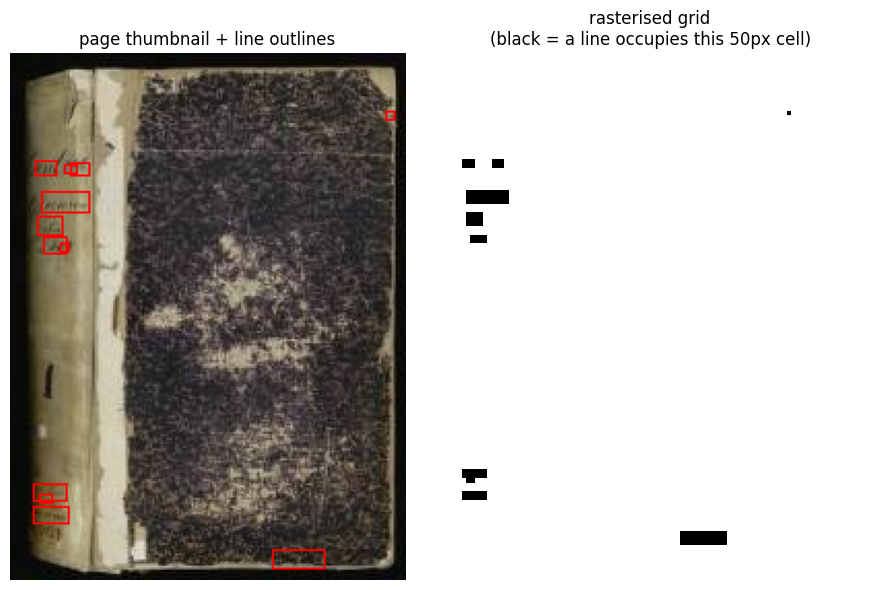


this page's 3 most frequent local 3x3 patterns (1 = a line occupies that grid cell):
  occurs 11170x:
    0 0 0
    0 0 0
    0 0 0
  occurs 31x:
    0 0 1
    0 0 1
    0 0 1
  occurs 31x:
    0 1 1
    0 1 1
    0 1 1


In [4]:
import numpy as np
import matplotlib.pyplot as plt

example_page_id = pages[0].id
example_idx = grid_pattern.id2idx[example_page_id]
example_grid = grid_pattern.doc_grid_points[example_idx]
print(f"example page: {example_page_id}")
print(f"grid shape: {example_grid.shape} cells of {grid_pattern.unit_size}px each "
      f"({example_grid.shape[0] * grid_pattern.unit_size}x"
      f"{example_grid.shape[1] * grid_pattern.unit_size}px)")
print(f"{grid_pattern.vocab_size} distinct {grid_pattern.pattern_size}x{grid_pattern.pattern_size} "
      f"patterns occur across this corpus's {len(pages)} pages")

fig, axes = plt.subplots(1, 2, figsize=(9, 6))
axes[0].imshow(draw_page_outline(page_by_id[example_page_id]))
axes[0].set_title('page thumbnail + line outlines')
axes[0].axis('off')
axes[1].imshow(example_grid.T, cmap='Greys', origin='upper', aspect='auto')
axes[1].set_title(f'rasterised grid\n(black = a line occupies this {grid_pattern.unit_size}px cell)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"\nthis page's 3 most frequent local {grid_pattern.pattern_size}x{grid_pattern.pattern_size} "
      "patterns (1 = a line occupies that grid cell):")
for pattern, count in grid_pattern.doc_pf(example_page_id).most_common(3):
    window = np.array(pattern, dtype=int).reshape(grid_pattern.pattern_size, grid_pattern.pattern_size)
    print(f"  occurs {count}x:")
    for row in window:
        print("   ", ' '.join(str(v) for v in row))

## Sanity-check the clusters against simple structural stats

These stats (region/line counts) aren't what the clustering is based on, so a clear difference
between clusters here is independent evidence that the clusters correspond to genuinely
different page structures, not an artefact of the layout features themselves.

In [5]:
stats_rows = [{'page_id': page.id, 'n_regions': len(page.text_regions), 'n_lines': len(page.get_lines()),
              'cluster': clusters[page.id]} for page in pages]
stats_df = pd.DataFrame(stats_rows)
stats_df.groupby('cluster')[['n_regions', 'n_lines']].agg(['mean', 'std', 'count'])

n_regions                      n_lines                 
               mean        std count        mean        std count
cluster                                                          
-1        64.746988  32.547842    83   64.746988  32.547842    83
 0       105.714286  58.939840     7  105.714286  58.939840     7
 1        51.400000  11.276327    10   51.400000  11.276327    10

## Look at example pages from each cluster

Reusing `draw_page_outline` from above, show two example pages for *every* cluster (including
noise, `-1`) side by side with the structural stats above -- not just a hand-picked couple, so
you can see what the clustering actually grouped together across the board.

In [6]:
def show_cluster_examples(cluster_id, n=2):
    page_ids = clusters[clusters == cluster_id].index[:n]
    label = 'noise' if cluster_id == -1 else f'cluster {cluster_id}'
    print(f"{label}: {list(page_ids)}")
    images = [draw_page_outline(page_by_id[page_id]) for page_id in page_ids]
    if not images:
        return None
    width = sum(im.width for im in images)
    height = max(im.height for im in images)
    combined = Image.new('RGB', (width, height), 'white')
    x = 0
    for im in images:
        combined.paste(im, (x, 0))
        x += im.width
    return combined

noise: ['NL-HaNA_2.10.50_1_0001.jpg', 'NL-HaNA_2.10.50_1_0004.jpg-recto']


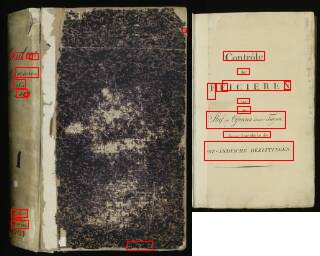

cluster 0: ['NL-HaNA_2.10.50_1_0006.jpg-verso', 'NL-HaNA_2.10.50_1_0019.jpg']


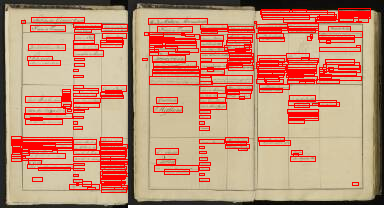

cluster 1: ['NL-HaNA_2.10.50_1_0007.jpg-verso', 'NL-HaNA_2.10.50_1_0018.jpg-verso']


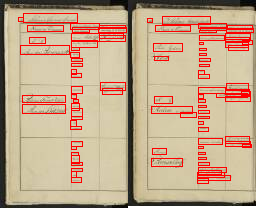

In [7]:
from IPython.display import display

for cluster_id in sorted(clusters.unique()):
    display(show_cluster_examples(cluster_id))

## Visualise with UMAP

Project the (L2-normalised) TF-IDF vectors to 2D with `colour_clustering.project_umap` -- reusing
the same UMAP helper already used for colour clustering -- purely for visual inspection of how
well-separated the clusters are.

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


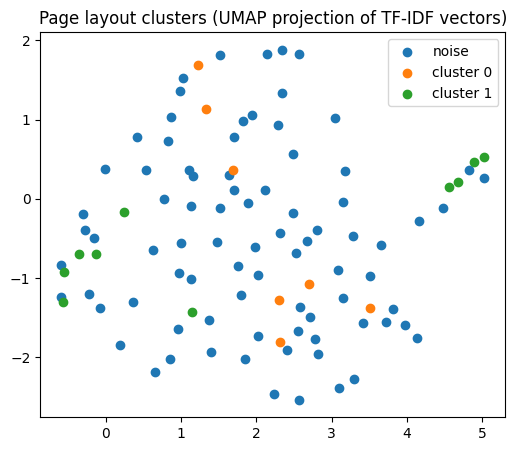

In [8]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

from archival_structures.clustering.colour_clustering import project_umap

umap_coords = project_umap(normalize(grid_pattern.tfidf), n_neighbors=10)

fig, ax = plt.subplots(figsize=(6, 5))
for cluster_id in sorted(clusters.unique()):
    mask = (clusters.values == cluster_id)
    label = 'noise' if cluster_id == -1 else f'cluster {cluster_id}'
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1], label=label)
ax.legend()
ax.set_title('Page layout clusters (UMAP projection of TF-IDF vectors)')
plt.show()